In [4]:
!pip install openpyxl arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 22.9 MB/s eta 0:00:00


--- Caricamento dati da: Zeri_Tommaso.xlsx (Foglio: Ex.1) ---
Dati caricati con successo: 6580 osservazioni.
Anteprima dati elaborati:
            LogPrice  scaled_ret
Date                            
2000-01-04  0.004000    0.400000
2000-01-05 -0.450075  -45.407549
2000-01-06 -0.839182  -38.910613
2000-01-07 -0.939597  -10.041514
2000-01-10 -0.847678    9.191862


--- Inizio Grid Search Completa (p, q, o) ---
Test in corso... (Attendere, potrebbe richiedere alcuni minuti)
--- Grid Search Completata: 72 modelli testati con successo ---

=== RANKING TOP 5 MODELS (Criterio: Minimo BIC) ===
          Model   Dist  p  o  q           BIC
0   GARCH (Std)      t  1  0  1  58829.880519
1   GARCH (Std)  skewt  1  0  1  58836.523482
2  EGARCH (o=0)      t  1  0  1  58836.579160
3  APARCH (o=0)      t  1  0  1  58837.293638
4     GJR-GARCH      t  1  1  1  58837.431805

=== WINNER ===
Model: GARCH (Std) | Dist: t
Params: p=1, o=0, q=1

=== BEST MODEL DIAGNOSTICS ===
                        Consta

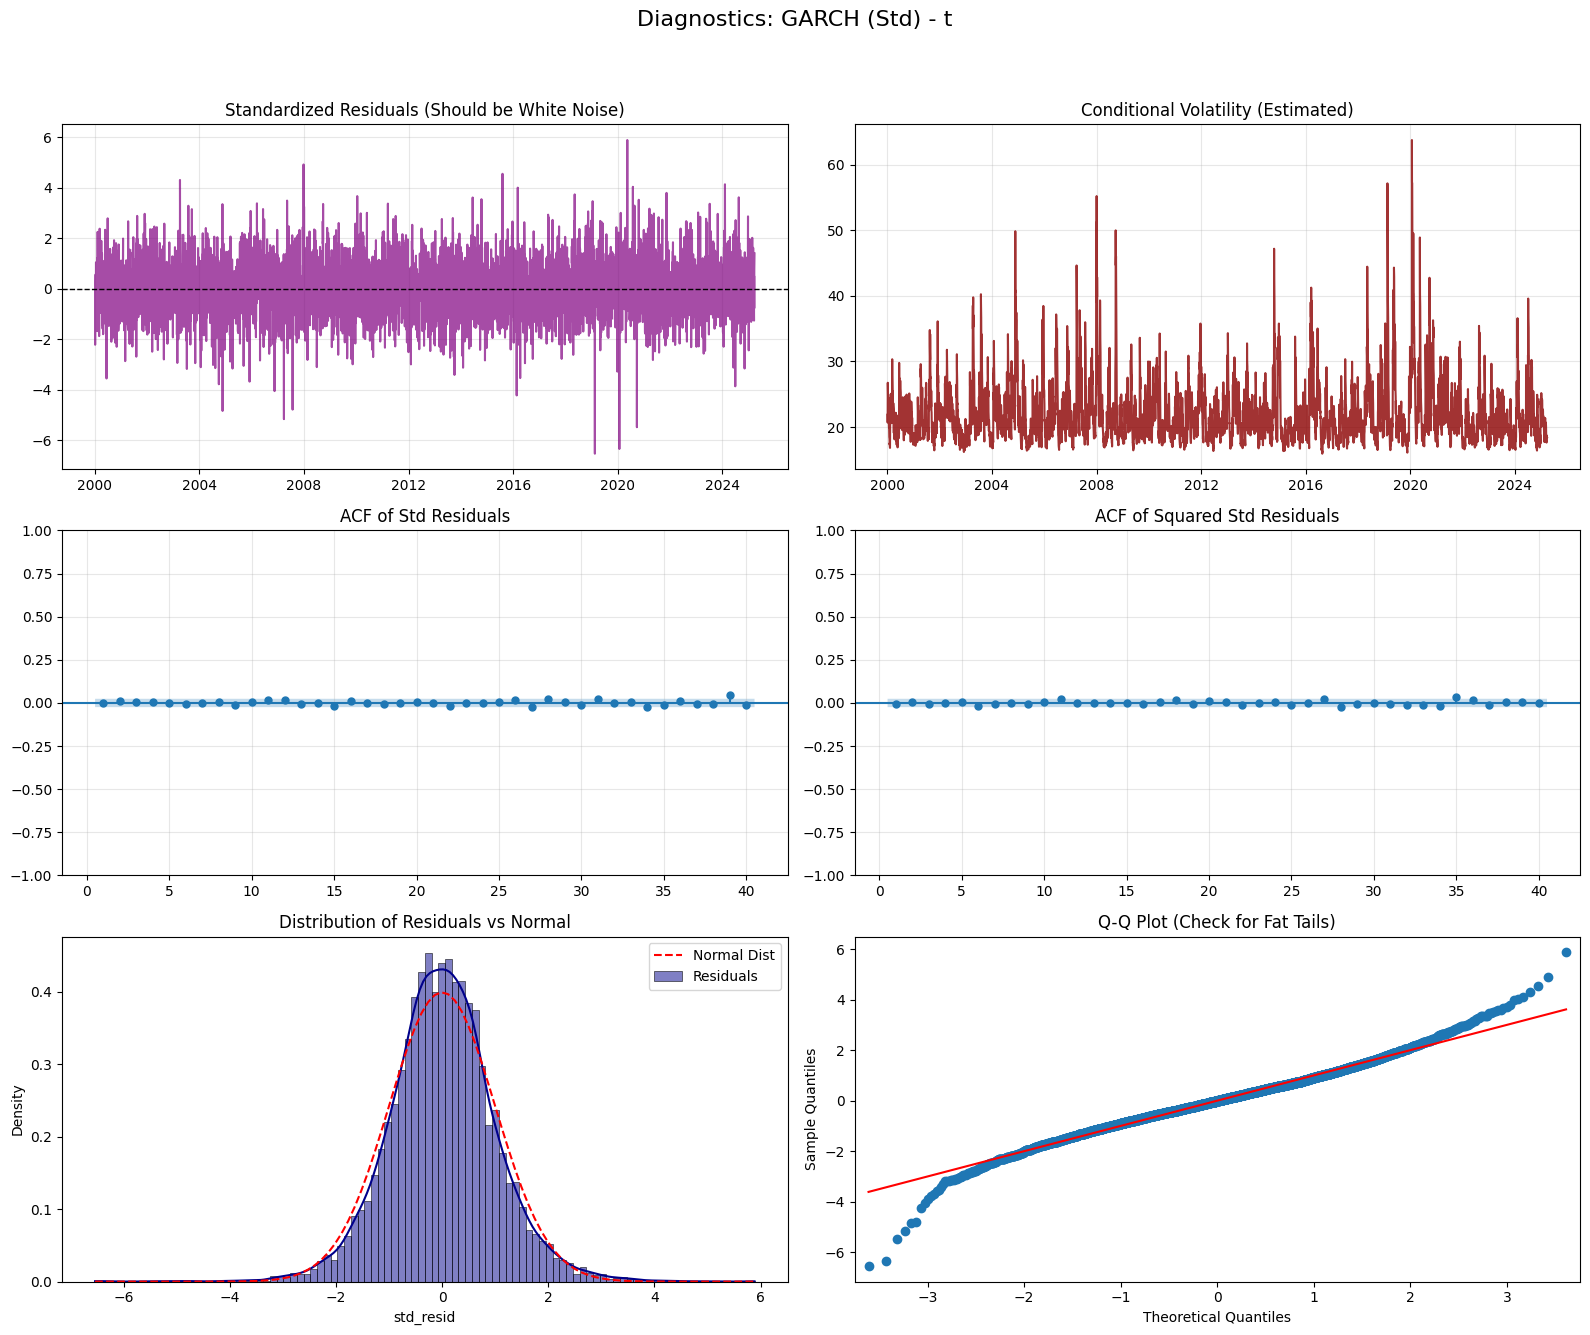

In [5]:
# -----------------------------------------------------------------------------
# SETUP INIZIALE
# -----------------------------------------------------------------------------

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from arch import arch_model

# Disabilitiamo i warning per pulizia output (convergenza modelli, ecc.)
warnings.filterwarnings("ignore")

class GarchGridSearchExcel:
    def __init__(self, file_path, sheet_name):
        """
        Classe per Grid Search GARCH su dati da file Excel.

        :param file_path: Percorso del file Excel (es. 'Zeri_Tommaso.xlsx')
        :param sheet_name: Nome del foglio di lavoro (es. 'Ex.1')
        """
        self.file_path = file_path
        self.sheet_name = sheet_name
        self.data = None
        self.results_table = None
        self.best_model_result = None

    def load_data(self):
        print(f"--- Caricamento dati da: {self.file_path} (Foglio: {self.sheet_name}) ---")
        try:
            # Lettura del file Excel
            # Si assume che la prima riga contenga le intestazioni (es. 'Date', 'Log Price')
            # Se non ci sono intestazioni, aggiungere header=None
            df = pd.read_excel(self.file_path, sheet_name=self.sheet_name)

            # --- SELEZIONE E PULIZIA DATI ---
            # Prendiamo le prime due colonne indipendentemente dal nome
            # Colonna A (indice 0) = Date
            # Colonna B (indice 1) = Log Prezzi
            df = df.iloc[:, [0, 1]]
            df.columns = ['Date', 'LogPrice']

            # Conversione in formato data e impostazione indice
            df['Date'] = pd.to_datetime(df['Date'])
            df.set_index('Date', inplace=True)

            # --- CALCOLO RENDIMENTI ---
            # Poiché la colonna B contiene già i logaritmi dei prezzi (p_t),
            # il rendimento logaritmico (r_t) è semplicemente la differenza:
            # r_t = p_t - p_{t-1}
            df['log_ret'] = df['LogPrice'].diff()

            # Rimozione dei valori mancanti (il primo dato diventa NaN dopo il diff)
            self.data = df.dropna()

            # SCALING: Moltiplichiamo per 100 per stabilità numerica nei modelli GARCH
            # (I solutori lavorano meglio con volori tipo 1.5 che 0.015)
            self.data['scaled_ret'] = self.data['log_ret'] * 100

            print(f"Dati caricati con successo: {len(self.data)} osservazioni.")
            print("Anteprima dati elaborati:")
            print(self.data[['LogPrice', 'scaled_ret']].head())
            print("\n")

        except Exception as e:
            print(f"ERRORE nel caricamento dati: {e}")
            print("Verifica che il file 'Zeri_Tommaso.xlsx' sia nella stessa cartella dello script.")
            # Se necessario, decommentare per il traceback completo:
            # import traceback; traceback.print_exc()

    def run_search(self):
        if self.data is None:
            self.load_data()
            if self.data is None: return # Stop se il caricamento fallisce

        print(f"--- Inizio Grid Search Completa (p, q, o) ---")
        print("Test in corso... (Attendere, potrebbe richiedere alcuni minuti)")

        # --- PARAMETRI DELLA GRIGLIA ---
        # Distribuzioni
        dists = ['Normal', 't', 'skewt']
        # Ordini dei lag
        ps = [1, 2]
        qs = [1, 2]
        # Asimmetria (0 = simmetrico, 1 = asimmetrico/GJR)
        os = [0, 1]
        # Famiglie
        vol_types = ['GARCH', 'EGARCH', 'APARCH']

        results_list = []
        total_combos = 0

        for vol in vol_types:
            for dist in dists:
                for p in ps:
                    for q in qs:
                        for o in os:
                            # --- FILTRI LOGICI ---
                            # GARCH Standard richiede o=0
                            if vol == 'GARCH' and o == 1:
                                model_name = "GJR-GARCH" # GARCH con termine asimmetrico
                            elif vol == 'GARCH' and o == 0:
                                model_name = "GARCH (Std)"
                            else:
                                model_name = f"{vol} (o={o})"

                            try:
                                # Costruzione Modello
                                am = arch_model(self.data['scaled_ret'],
                                                vol=vol,
                                                p=p, o=o, q=q,
                                                dist=dist, mean='Constant')

                                # Fitting
                                res = am.fit(disp='off')

                                results_list.append({
                                    'Model': model_name,
                                    'Dist': dist,
                                    'p': p, 'o': o, 'q': q,
                                    'AIC': res.aic,
                                    'BIC': res.bic,
                                    'LogLik': res.loglikelihood,
                                    'Result_Object': res
                                })
                                total_combos += 1

                            except Exception:
                                # Alcuni modelli complessi potrebbero non convergere
                                pass

        # Creazione DataFrame Risultati
        results_df = pd.DataFrame(results_list)

        if results_df.empty:
            print("Nessun modello è riuscito a convergere.")
            return

        # Ordinamento per BIC (Migliore = Più Basso)
        self.results_table = results_df.sort_values(by='BIC', ascending=True).reset_index(drop=True)
        self.best_model_result = self.results_table.iloc[0]['Result_Object']

        print(f"--- Grid Search Completata: {total_combos} modelli testati con successo ---\n")

    def show_top_models(self, n=5):
        if self.results_table is None:
            return

        print(f"=== RANKING TOP {n} MODELS (Criterio: Minimo BIC) ===")
        cols_to_show = ['Model', 'Dist', 'p', 'o', 'q', 'BIC']
        print(self.results_table[cols_to_show].head(n))

        best = self.results_table.iloc[0]
        print("\n=== WINNER ===")
        print(f"Model: {best['Model']} | Dist: {best['Dist']}")
        print(f"Params: p={best['p']}, o={best['o']}, q={best['q']}")

    def diagnose_best_model(self):
        """
        Esegue una diagnostica visiva completa sul modello vincitore.
        """
        if self.best_model_result is None:
            print("Esegui prima run_search()!")
            return

        res = self.best_model_result
        std_resid = res.std_resid # Residui Standardizzati

        print("\n=== BEST MODEL DIAGNOSTICS ===")
        print(res.summary())

        # Creazione Dashboard Plot 3x2
        fig, axes = plt.subplots(3, 2, figsize=(16, 14))
        title_text = f"Diagnostics: {self.results_table.iloc[0]['Model']} - {self.results_table.iloc[0]['Dist']}"
        fig.suptitle(title_text, fontsize=16)

        # 1. Residui Standardizzati (Serie Storica)
        axes[0, 0].plot(std_resid, color='purple', alpha=0.7)
        axes[0, 0].set_title("Standardized Residuals (Should be White Noise)")
        axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
        axes[0, 0].grid(True, alpha=0.3)

        # 2. Volatilità Condizionale
        axes[0, 1].plot(res.conditional_volatility, color='darkred', alpha=0.8)
        axes[0, 1].set_title("Conditional Volatility (Estimated)")
        axes[0, 1].grid(True, alpha=0.3)

        # 3. ACF dei Residui Standardizzati (Media)
        sm.graphics.tsa.plot_acf(std_resid, ax=axes[1, 0], lags=40, zero=False, title="ACF of Std Residuals")
        axes[1, 0].grid(True, alpha=0.3)

        # 4. ACF dei Residui al Quadrato (Varianza)
        sm.graphics.tsa.plot_acf(np.square(std_resid), ax=axes[1, 1], lags=40, zero=False, title="ACF of Squared Std Residuals")
        axes[1, 1].grid(True, alpha=0.3)

        # 5. Istogramma vs Densità
        try:
            import seaborn as sns
            sns.histplot(std_resid, kde=True, stat="density", ax=axes[2, 0], color="darkblue", label="Residuals")
        except ImportError:
            axes[2, 0].hist(std_resid, bins=50, density=True, color="darkblue", alpha=0.6, label="Residuals")

        # Sovrapposizione Normale teorica
        x = np.linspace(std_resid.min(), std_resid.max(), 100)
        axes[2, 0].plot(x, stats.norm.pdf(x), 'r--', label="Normal Dist")
        axes[2, 0].set_title("Distribution of Residuals vs Normal")
        axes[2, 0].legend()

        # 6. Q-Q Plot
        sm.qqplot(std_resid, line='s', color="darkblue", ax=axes[2, 1])
        axes[2, 1].set_title("Q-Q Plot (Check for Fat Tails)")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# -----------------------------------------------------------------------------
# ESECUZIONE PRINCIPALE
# -----------------------------------------------------------------------------
if __name__ == "__main__":

    # CONFIGURAZIONE FILE
    nome_file = "Zeri_Tommaso.xlsx"
    nome_foglio = "Ex.1"

    # 1. Inizializzazione
    app = GarchGridSearchExcel(nome_file, nome_foglio)

    # 2. Caricamento Dati
    app.load_data()

    # 3. Esecuzione Grid Search (se i dati sono stati caricati)
    if app.data is not None:
        app.run_search()

        # 4. Mostra Top 5 Modelli
        app.show_top_models(n=5)

        # 5. Grafici Diagnostici del Vincitore
        app.diagnose_best_model()